In [16]:
import os

import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["WANDB_API_KEY"] = (
    ""
)

In [17]:
import pandas as pd
import wandb

api = wandb.Api()

PROJECT = "julian_oelhaf/fc-fl-comparison"
runs = api.runs(PROJECT)

records = []
for run in runs:
    summary = run.summary._json_dict
    config = {k: v for k, v in run.config.items() if not k.startswith("_")}

    record = {
        "run_id": run.id,
        "run_name": run.name,
        "state": run.state,
        "created_at": run.created_at,
        "group": run.group,
        "job_type": run.job_type,
        "tags": ",".join(run.tags) if run.tags else "",
    }

    # prefix to avoid collisions
    record.update({f"summary.{k}": v for k, v in summary.items()})
    record.update({f"config.{k}": v for k, v in config.items()})

    records.append(record)

runs_df = pd.DataFrame(records)

# keep only completed runs
runs_df = runs_df[runs_df["state"] == "finished"].copy()

print(f"Loaded {len(runs_df)} finished runs")
print(runs_df.shape)
print(runs_df.columns.tolist())


# Convert to datetime (UTC)
runs_df["created_at"] = pd.to_datetime(runs_df["created_at"], utc=True)

# Define "today" (also in UTC)
today = pd.Timestamp.utcnow().normalize()

runs_today = runs_df[runs_df["created_at"] >= today].copy()

print(f"Runs today: {len(runs_today)}")

Loaded 530 finished runs
(530, 103)
['run_id', 'run_name', 'state', 'created_at', 'group', 'job_type', 'tags', 'summary._runtime', 'summary._step', 'summary._timestamp', 'summary._wandb', 'summary.best_fold_index', 'summary.completed', 'summary.cv/mean_mae', 'summary.cv/mean_r2', 'summary.cv/mean_rmse', 'summary.cv/std_mae', 'summary.cv/std_r2', 'summary.cv/std_rmse', 'summary.saved_model_path', 'config.task/type', 'config.model/name', 'config.cv/n_splits', 'config.hgb/max_iter', 'config.features/flat', 'config.hgb/max_depth', 'config.window/step_s', 'config.cv/random_state', 'config.window/length_s', 'config.dataset/topology', 'config.window/n_windows', 'config.hgb/learning_rate', 'config.task/target_label', 'config.window/n_timesteps', 'config.hgb/min_samples_leaf', 'config.features/per_timestep', 'config.hgb/l2_regularization', 'config.sparsity/current_loss', 'config.sparsity/voltage_loss', 'config.dataset/n_samples_total', 'config.sparsity/bus_failure_id', 'config.dataset/nominal_f

In [18]:
runs_today

,run_id,run_name,state,created_at,group,job_type,tags,summary._runtime,summary._step,summary._timestamp,...,summary.cv/oof/all_windows/f1_by_fault_line,summary.cv/oof/fault_only/f1_by_fault_line,summary.cv/oof/fault_only_fault_start/f1_by_fault_line,summary.cv/oof/fault_start_only/f1_by_fault_line,config.ablation/mode,config.ablation/enabled,config.ablation/n_relays,config.ablation/relay_index,config.ablation/features_per_relay,config.ablation/relay_indices
508,uma7wu6p,tough-waterfall-777,finished,2026-03-27 08:25:55+00:00,None,None,,59.0,4.0,1.774600e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
509,476xme1z,glorious-spaceship-778,finished,2026-03-27 08:27:38+00:00,None,None,,239.0,4.0,1.774600e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
510,hoqdk6o9,golden-bird-779,finished,2026-03-27 08:28:10+00:00,None,None,,106.0,4.0,1.774600e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
511,dl7a88h3,neat-pine-780,finished,2026-03-27 08:30:19+00:00,None,None,,119.0,4.0,1.774600e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
512,b0oeg77t,good-yogurt-781,finished,2026-03-27 08:31:26+00:00,None,None,,128.0,13.0,1.774600e+09,...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,full,True,8.0,0.0,6.0,[]
513,jling4nx,classic-glade-782,finished,2026-03-27 08:32:52+00:00,None,None,,408.0,4.0,1.774601e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
514,e6u5915d,effortless-shape-783,finished,2026-03-27 08:34:15+00:00,None,None,,286.0,13.0,1.774601e+09,...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,full,True,8.0,0.0,6.0,[]
515,3rq0r9f1,lemon-voice-784,finished,2026-03-27 08:39:32+00:00,None,None,,591.0,13.0,1.774601e+09,...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,{'_latest_artifact_path': 'wandb-client-artifa...,full,True,8.0,0.0,6.0,[]
516,hbgb774n,lyric-galaxy-785,finished,2026-03-27 08:39:58+00:00,None,None,,558.0,4.0,1.774601e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]
517,tgfwfb4n,stilted-sponge-786,finished,2026-03-27 08:50:02+00:00,None,None,,238.0,4.0,1.774602e+09,...,NaN,NaN,NaN,NaN,full,True,8.0,0.0,6.0,[]


In [30]:
# Create overview of: task (config.task/target_label), model (config.model/name), stride (config.window/step_s), window (config.window/length_s), report number of runs per combination
runs_today["task"] = runs_today["config.task/target_label"]
runs_today["model"] = runs_today["config.model/name"]
runs_today["stride"] = runs_today["config.window/step_s"]
runs_today["window"] = runs_today["config.window/length_s"]

overview = (
    runs_today.groupby(["task", "model", "window", "stride"])
    .size()
    .reset_index(name="num_runs")
    .sort_values(by="num_runs", ascending=False)
)

# Expected number of rows is 2 (tasks) * 2 (models) * 3 windows * 3 strides = 36; minus 2 runs (10ms cant run with 20ms or 50 stride) = 34; minus 1 run (20ms cant run with 50 stride) = 33
print(f"Overview shape: {overview.shape}")


overview

Overview shape: (36, 5)


,task,model,window,stride,num_runs
0,event_type,hist_gradient_boosting_classifier,0.01,0.005,1
1,event_type,hist_gradient_boosting_classifier,0.01,0.010,1
2,event_type,hist_gradient_boosting_classifier,0.02,0.005,1
3,event_type,hist_gradient_boosting_classifier,0.02,0.010,1
4,event_type,hist_gradient_boosting_classifier,0.02,0.020,1
5,event_type,hist_gradient_boosting_classifier,0.05,0.005,1
6,event_type,hist_gradient_boosting_classifier,0.05,0.010,1
7,event_type,hist_gradient_boosting_classifier,0.05,0.020,1
8,event_type,hist_gradient_boosting_classifier,0.05,0.050,1
9,event_type,mlp_classifier,0.01,0.005,1


In [53]:
import pandas as pd
import numpy as np

# ----------------------------
# 1) Common preparation
# ----------------------------
df_analysis = runs_today.copy()

df_analysis["task_type"] = df_analysis["config.task/type"].astype(str).str.strip()
df_analysis["task_label"] = (
    df_analysis["config.task/target_label"].astype(str).str.strip()
)
df_analysis["model"] = df_analysis["config.model/name"].astype(str).str.strip()
df_analysis["window"] = pd.to_numeric(
    df_analysis["config.window/length_s"], errors="coerce"
)
df_analysis["stride"] = pd.to_numeric(
    df_analysis["config.window/step_s"], errors="coerce"
)

BASELINE_STRIDE = 0.005

# Metrics
FC_METRIC = "summary.cv/mean_f1_score"
FL_METRIC = "summary.cv/mean_mae"

df_analysis["fc_metric"] = pd.to_numeric(df_analysis.get(FC_METRIC), errors="coerce")
df_analysis["fl_metric"] = pd.to_numeric(df_analysis.get(FL_METRIC), errors="coerce")

In [54]:
# ----------------------------
# 2) FC analysis
# ----------------------------
fc_df = df_analysis[df_analysis["task_type"] == "multiclass"].copy()

print(f"FC runs: {len(fc_df)}")

# A. Coverage overview: which model/window combinations have which strides?
fc_coverage = (
    fc_df.groupby(["model", "window"])["stride"]
    .apply(lambda s: sorted(s.dropna().unique().tolist()))
    .reset_index(name="available_strides")
    .sort_values(["model", "window"])
)

print("\nFC coverage:")
print(fc_coverage.to_string(index=False))

# B. Main summary table: metric by model x window x stride
fc_summary = (
    fc_df.groupby(["model", "window", "stride"], dropna=False)
    .agg(
        num_runs=("fc_metric", "size"),
        f1_mean=("fc_metric", "mean"),
        f1_std=("fc_metric", "std"),
        f1_min=("fc_metric", "min"),
        f1_max=("fc_metric", "max"),
    )
    .reset_index()
    .sort_values(["model", "window", "stride"])
)

print("\nFC summary:")
print(fc_summary.to_string(index=False))

FC runs: 18

FC coverage:
                            model  window         available_strides
hist_gradient_boosting_classifier    0.01             [0.005, 0.01]
hist_gradient_boosting_classifier    0.02       [0.005, 0.01, 0.02]
hist_gradient_boosting_classifier    0.05 [0.005, 0.01, 0.02, 0.05]
                   mlp_classifier    0.01             [0.005, 0.01]
                   mlp_classifier    0.02       [0.005, 0.01, 0.02]
                   mlp_classifier    0.05 [0.005, 0.01, 0.02, 0.05]

FC summary:
                            model  window  stride  num_runs  f1_mean  f1_std   f1_min   f1_max
hist_gradient_boosting_classifier    0.01   0.005         1 0.418111     NaN 0.418111 0.418111
hist_gradient_boosting_classifier    0.01   0.010         1 0.517453     NaN 0.517453 0.517453
hist_gradient_boosting_classifier    0.02   0.005         1 0.738005     NaN 0.738005 0.738005
hist_gradient_boosting_classifier    0.02   0.010         1 0.966435     NaN 0.966435 0.966435
hist_gradi

In [55]:
# C. Compare each stride against the baseline stride (5 ms)
fc_baseline = fc_summary[fc_summary["stride"] == BASELINE_STRIDE].rename(
    columns={
        "f1_mean": "f1_baseline",
        "f1_std": "f1_baseline_std",
        "num_runs": "baseline_num_runs",
    }
)[["model", "window", "f1_baseline", "f1_baseline_std", "baseline_num_runs"]]

fc_comparison = fc_summary.merge(fc_baseline, on=["model", "window"], how="left")

fc_comparison["delta_f1_vs_baseline"] = (
    fc_comparison["f1_mean"] - fc_comparison["f1_baseline"]
)

print("\nFC comparison vs baseline:")
print(
    fc_comparison[
        [
            "model",
            "window",
            "stride",
            "num_runs",
            "f1_mean",
            "f1_baseline",
            "delta_f1_vs_baseline",
        ]
    ].to_string(index=False)
)


FC comparison vs baseline:
                            model  window  stride  num_runs  f1_mean  f1_baseline  delta_f1_vs_baseline
hist_gradient_boosting_classifier    0.01   0.005         1 0.418111     0.418111              0.000000
hist_gradient_boosting_classifier    0.01   0.010         1 0.517453     0.418111              0.099342
hist_gradient_boosting_classifier    0.02   0.005         1 0.738005     0.738005              0.000000
hist_gradient_boosting_classifier    0.02   0.010         1 0.966435     0.738005              0.228429
hist_gradient_boosting_classifier    0.02   0.020         1 0.968885     0.738005              0.230880
hist_gradient_boosting_classifier    0.05   0.005         1 0.981921     0.981921              0.000000
hist_gradient_boosting_classifier    0.05   0.010         1 0.977433     0.981921             -0.004488
hist_gradient_boosting_classifier    0.05   0.020         1 0.978665     0.981921             -0.003256
hist_gradient_boosting_classifier   

In [56]:
# D. Compact pivot: easiest to interpret model-wise and window-wise
fc_pivot = fc_summary.pivot_table(
    index=["model", "window"], columns="stride", values="f1_mean"
).reset_index()

for stride_col in [0.01, 0.02]:
    if BASELINE_STRIDE in fc_pivot.columns and stride_col in fc_pivot.columns:
        fc_pivot[f"delta_f1_{stride_col:.3f}_vs_{BASELINE_STRIDE:.3f}"] = (
            fc_pivot[stride_col] - fc_pivot[BASELINE_STRIDE]
        )

print("\nFC pivot:")
print(fc_pivot.to_string(index=False))


FC pivot:
                            model  window    0.005     0.01     0.02     0.05  delta_f1_0.010_vs_0.005  delta_f1_0.020_vs_0.005
hist_gradient_boosting_classifier    0.01 0.418111 0.517453      NaN      NaN                 0.099342                      NaN
hist_gradient_boosting_classifier    0.02 0.738005 0.966435 0.968885      NaN                 0.228429                 0.230880
hist_gradient_boosting_classifier    0.05 0.981921 0.977433 0.978665 0.985821                -0.004488                -0.003256
                   mlp_classifier    0.01 0.989434 0.990966      NaN      NaN                 0.001532                      NaN
                   mlp_classifier    0.02 0.992808 0.983182 0.992143      NaN                -0.009626                -0.000665
                   mlp_classifier    0.05 0.989512 0.986932 0.988639 0.983722                -0.002580                -0.000873


In [57]:
# E. Optional: model-wise average effect across windows
fc_modelwise_effect = (
    fc_comparison[fc_comparison["stride"] != BASELINE_STRIDE]
    .groupby(["model", "stride"], dropna=False)
    .agg(
        mean_delta_f1=("delta_f1_vs_baseline", "mean"),
        std_delta_f1=("delta_f1_vs_baseline", "std"),
        n_windows=("window", "nunique"),
    )
    .reset_index()
    .sort_values(["model", "stride"])
)

print("\nFC model-wise average stride effect:")
print(fc_modelwise_effect.to_string(index=False))


FC model-wise average stride effect:
                            model  stride  mean_delta_f1  std_delta_f1  n_windows
hist_gradient_boosting_classifier    0.01       0.107761      0.116687          3
hist_gradient_boosting_classifier    0.02       0.113812      0.165559          2
hist_gradient_boosting_classifier    0.05       0.003900           NaN          1
                   mlp_classifier    0.01      -0.003558      0.005643          3
                   mlp_classifier    0.02      -0.000769      0.000147          2
                   mlp_classifier    0.05      -0.005789           NaN          1


In [58]:
# F. Optional: window-wise average effect across models
fc_windowwise_effect = (
    fc_comparison[fc_comparison["stride"] != BASELINE_STRIDE]
    .groupby(["window", "stride"], dropna=False)
    .agg(
        mean_delta_f1=("delta_f1_vs_baseline", "mean"),
        std_delta_f1=("delta_f1_vs_baseline", "std"),
        n_models=("model", "nunique"),
    )
    .reset_index()
    .sort_values(["window", "stride"])
)

print("\nFC window-wise average stride effect:")
print(fc_windowwise_effect.to_string(index=False))


FC window-wise average stride effect:
 window  stride  mean_delta_f1  std_delta_f1  n_models
   0.01    0.01       0.050437      0.069162         2
   0.02    0.01       0.109402      0.168331         2
   0.02    0.02       0.115107      0.163727         2
   0.05    0.01      -0.003534      0.001349         2
   0.05    0.02      -0.002064      0.001685         2
   0.05    0.05      -0.000945      0.006851         2


# ----------------------------
# 3) FL analysis
# ----------------------------

In [59]:
fl_df = df_analysis[df_analysis["task"] == "y_fault_location"].copy()

print(f"FL runs: {len(fl_df)}")

# A. Coverage overview
fl_coverage = (
    fl_df.groupby(["model", "window"])["stride"]
    .apply(lambda s: sorted(s.dropna().unique().tolist()))
    .reset_index(name="available_strides")
    .sort_values(["model", "window"])
)

print("\nFL coverage:")
print(fl_coverage.to_string(index=False))

# B. Main summary table: metric by model x window x stride
fl_summary = (
    fl_df.groupby(["model", "window", "stride"], dropna=False)
    .agg(
        num_runs=("fl_metric", "size"),
        mae_mean=("fl_metric", "mean"),
        mae_std=("fl_metric", "std"),
        mae_min=("fl_metric", "min"),
        mae_max=("fl_metric", "max"),
    )
    .reset_index()
    .sort_values(["model", "window", "stride"])
)

print("\nFL summary:")
print(fl_summary.to_string(index=False))

FL runs: 18

FL coverage:
                           model  window         available_strides
hist_gradient_boosting_regressor    0.01             [0.005, 0.01]
hist_gradient_boosting_regressor    0.02       [0.005, 0.01, 0.02]
hist_gradient_boosting_regressor    0.05 [0.005, 0.01, 0.02, 0.05]
                   mlp_regressor    0.01             [0.005, 0.01]
                   mlp_regressor    0.02       [0.005, 0.01, 0.02]
                   mlp_regressor    0.05 [0.005, 0.01, 0.02, 0.05]

FL summary:
                           model  window  stride  num_runs  mae_mean  mae_std   mae_min   mae_max
hist_gradient_boosting_regressor    0.01   0.005         1 14.646097      NaN 14.646097 14.646097
hist_gradient_boosting_regressor    0.01   0.010         1 14.646097      NaN 14.646097 14.646097
hist_gradient_boosting_regressor    0.02   0.005         1 14.783462      NaN 14.783462 14.783462
hist_gradient_boosting_regressor    0.02   0.010         1 15.063735      NaN 15.063735 15.063735
hi

In [61]:
# C. Compare each stride against the baseline stride (5 ms)
fl_baseline = fl_summary[fl_summary["stride"] == BASELINE_STRIDE].rename(
    columns={
        "mae_mean": "mae_baseline",
        "mae_std": "mae_baseline_std",
        "num_runs": "baseline_num_runs",
    }
)[["model", "window", "mae_baseline", "mae_baseline_std", "baseline_num_runs"]]

fl_comparison = fl_summary.merge(fl_baseline, on=["model", "window"], how="left")

fl_comparison["delta_mae_vs_baseline"] = (
    fl_comparison["mae_mean"] - fl_comparison["mae_baseline"]
)
fl_comparison["improvement_vs_baseline"] = -fl_comparison[
    "delta_mae_vs_baseline"
]  # positive = better

print("\nFL comparison vs baseline:")
print(
    fl_comparison[
        [
            "model",
            "window",
            "stride",
            "num_runs",
            "mae_mean",
            "mae_baseline",
            "delta_mae_vs_baseline",
            "improvement_vs_baseline",
        ]
    ].to_string(index=False)
)


FL comparison vs baseline:
                           model  window  stride  num_runs  mae_mean  mae_baseline  delta_mae_vs_baseline  improvement_vs_baseline
hist_gradient_boosting_regressor    0.01   0.005         1 14.646097     14.646097               0.000000                -0.000000
hist_gradient_boosting_regressor    0.01   0.010         1 14.646097     14.646097               0.000000                -0.000000
hist_gradient_boosting_regressor    0.02   0.005         1 14.783462     14.783462               0.000000                -0.000000
hist_gradient_boosting_regressor    0.02   0.010         1 15.063735     14.783462               0.280273                -0.280273
hist_gradient_boosting_regressor    0.02   0.020         1 14.426502     14.783462              -0.356960                 0.356960
hist_gradient_boosting_regressor    0.05   0.005         1 14.658286     14.658286               0.000000                -0.000000
hist_gradient_boosting_regressor    0.05   0.010       

In [62]:
# D. Compact pivot
fl_pivot = fl_summary.pivot_table(
    index=["model", "window"], columns="stride", values="mae_mean"
).reset_index()

for stride_col in [0.01, 0.02]:
    if BASELINE_STRIDE in fl_pivot.columns and stride_col in fl_pivot.columns:
        fl_pivot[f"delta_mae_{stride_col:.3f}_vs_{BASELINE_STRIDE:.3f}"] = (
            fl_pivot[stride_col] - fl_pivot[BASELINE_STRIDE]
        )
        fl_pivot[f"improvement_{stride_col:.3f}_vs_{BASELINE_STRIDE:.3f}"] = -fl_pivot[
            f"delta_mae_{stride_col:.3f}_vs_{BASELINE_STRIDE:.3f}"
        ]

print("\nFL pivot:")
print(fl_pivot.to_string(index=False))


FL pivot:
                           model  window     0.005      0.01      0.02      0.05  delta_mae_0.010_vs_0.005  improvement_0.010_vs_0.005  delta_mae_0.020_vs_0.005  improvement_0.020_vs_0.005
hist_gradient_boosting_regressor    0.01 14.646097 14.646097       NaN       NaN                  0.000000                   -0.000000                       NaN                         NaN
hist_gradient_boosting_regressor    0.02 14.783462 15.063735 14.426502       NaN                  0.280273                   -0.280273                 -0.356960                    0.356960
hist_gradient_boosting_regressor    0.05 14.658286 15.149360 15.300734 14.464148                  0.491075                   -0.491075                  0.642449                   -0.642449
                   mlp_regressor    0.01 10.661781 10.661781       NaN       NaN                  0.000000                   -0.000000                       NaN                         NaN
                   mlp_regressor    0.02 10.

In [63]:
# E. Optional: model-wise average effect across windows
fl_modelwise_effect = (
    fl_comparison[fl_comparison["stride"] != BASELINE_STRIDE]
    .groupby(["model", "stride"], dropna=False)
    .agg(
        mean_delta_mae=("delta_mae_vs_baseline", "mean"),
        std_delta_mae=("delta_mae_vs_baseline", "std"),
        mean_improvement=("improvement_vs_baseline", "mean"),
        n_windows=("window", "nunique"),
    )
    .reset_index()
    .sort_values(["model", "stride"])
)

print("\nFL model-wise average stride effect:")
print(fl_modelwise_effect.to_string(index=False))


FL model-wise average stride effect:
                           model  stride  mean_delta_mae  std_delta_mae  mean_improvement  n_windows
hist_gradient_boosting_regressor    0.01        0.257116       0.246355         -0.257116          3
hist_gradient_boosting_regressor    0.02        0.142744       0.706689         -0.142744          2
hist_gradient_boosting_regressor    0.05       -0.194138            NaN          0.194138          1
                   mlp_regressor    0.01        0.803641       0.778036         -0.803641          3
                   mlp_regressor    0.02        1.007065       1.021878         -1.007065          2
                   mlp_regressor    0.05        1.790990            NaN         -1.790990          1


In [64]:
# F. Optional: window-wise average effect across models
fl_windowwise_effect = (
    fl_comparison[fl_comparison["stride"] != BASELINE_STRIDE]
    .groupby(["window", "stride"], dropna=False)
    .agg(
        mean_delta_mae=("delta_mae_vs_baseline", "mean"),
        std_delta_mae=("delta_mae_vs_baseline", "std"),
        mean_improvement=("improvement_vs_baseline", "mean"),
        n_models=("model", "nunique"),
    )
    .reset_index()
    .sort_values(["window", "stride"])
)

print("\nFL window-wise average stride effect:")
print(fl_windowwise_effect.to_string(index=False))


FL window-wise average stride effect:
 window  stride  mean_delta_mae  std_delta_mae  mean_improvement  n_models
   0.01    0.01        0.000000       0.000000          0.000000         2
   0.02    0.01        0.568969       0.408279         -0.568969         2
   0.02    0.02       -0.036236       0.453572          0.036236         2
   0.05    0.01        1.022166       0.751076         -1.022166         2
   0.05    0.02        1.186045       0.768762         -1.186045         2
   0.05    0.05        0.798426       1.403698         -0.798426         2


In [65]:
fc_summary.to_csv("fc_stride_summary.csv", index=False)
fc_comparison.to_csv("fc_stride_vs_baseline.csv", index=False)
fc_pivot.to_csv("fc_stride_pivot.csv", index=False)

fl_summary.to_csv("fl_stride_summary.csv", index=False)
fl_comparison.to_csv("fl_stride_vs_baseline.csv", index=False)
fl_pivot.to_csv("fl_stride_pivot.csv", index=False)

print("Saved FC and FL stride analysis tables.")

Saved FC and FL stride analysis tables.


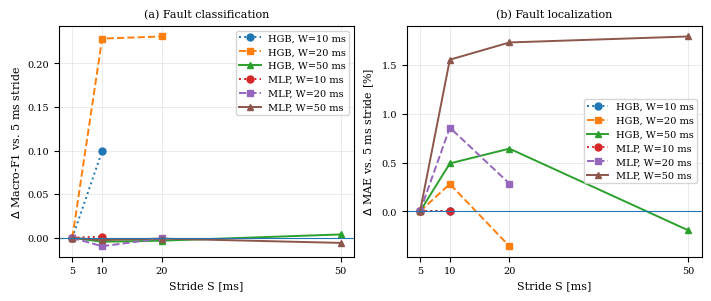

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Publication-ready stride sensitivity figure (IEEE / EPSR style)
# Two panels:
#   (a) Fault Classification: ΔF1 vs. stride
#   (b) Fault Localization: ΔMAE vs. stride
#
# Notes:
# - Values are taken directly from your pivot tables.
# - Baseline stride is 5 ms, so all curves start at 0 by definition.
# - Positive ΔF1 is better than baseline.
# - Positive ΔMAE is worse than baseline.
# ============================================================

# ----------------------------
# 1) Input data from your pivots
# ----------------------------
fc_rows = [
    {
        "model": "hist_gradient_boosting_classifier",
        "window": 0.01,
        "0.005": 0.418111,
        "0.01": 0.517453,
        "0.02": np.nan,
        "0.05": np.nan,
    },
    {
        "model": "hist_gradient_boosting_classifier",
        "window": 0.02,
        "0.005": 0.738005,
        "0.01": 0.966435,
        "0.02": 0.968885,
        "0.05": np.nan,
    },
    {
        "model": "hist_gradient_boosting_classifier",
        "window": 0.05,
        "0.005": 0.981921,
        "0.01": 0.977433,
        "0.02": 0.978665,
        "0.05": 0.985821,
    },
    {
        "model": "mlp_classifier",
        "window": 0.01,
        "0.005": 0.989434,
        "0.01": 0.990966,
        "0.02": np.nan,
        "0.05": np.nan,
    },
    {
        "model": "mlp_classifier",
        "window": 0.02,
        "0.005": 0.992808,
        "0.01": 0.983182,
        "0.02": 0.992143,
        "0.05": np.nan,
    },
    {
        "model": "mlp_classifier",
        "window": 0.05,
        "0.005": 0.989512,
        "0.01": 0.986932,
        "0.02": 0.988639,
        "0.05": 0.983722,
    },
]

fl_rows = [
    {
        "model": "hist_gradient_boosting_regressor",
        "window": 0.01,
        "0.005": 14.646097,
        "0.01": 14.646097,
        "0.02": np.nan,
        "0.05": np.nan,
    },
    {
        "model": "hist_gradient_boosting_regressor",
        "window": 0.02,
        "0.005": 14.783462,
        "0.01": 15.063735,
        "0.02": 14.426502,
        "0.05": np.nan,
    },
    {
        "model": "hist_gradient_boosting_regressor",
        "window": 0.05,
        "0.005": 14.658286,
        "0.01": 15.149360,
        "0.02": 15.300734,
        "0.05": 14.464148,
    },
    {
        "model": "mlp_regressor",
        "window": 0.01,
        "0.005": 10.661781,
        "0.01": 10.661781,
        "0.02": np.nan,
        "0.05": np.nan,
    },
    {
        "model": "mlp_regressor",
        "window": 0.02,
        "0.005": 10.195141,
        "0.01": 11.052806,
        "0.02": 10.479629,
        "0.05": np.nan,
    },
    {
        "model": "mlp_regressor",
        "window": 0.05,
        "0.005": 9.914551,
        "0.01": 11.467808,
        "0.02": 11.644194,
        "0.05": 11.705542,
    },
]

fc_df = pd.DataFrame(fc_rows)
fl_df = pd.DataFrame(fl_rows)

stride_cols = ["0.005", "0.01", "0.02", "0.05"]
stride_ms = np.array([5, 10, 20, 50], dtype=float)


# ----------------------------
# 2) Convert to delta vs baseline
# ----------------------------
def compute_delta_vs_baseline(df: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    baseline = out["0.005"]
    for col in value_cols:
        out[col] = out[col] - baseline
    return out


fc_delta = compute_delta_vs_baseline(fc_df, stride_cols)
fl_delta = compute_delta_vs_baseline(fl_df, stride_cols)

# ----------------------------
# 3) Plot styling
# ----------------------------
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "lines.markersize": 5,
        "grid.linewidth": 0.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# Grayscale-friendly style mapping
window_style = {
    0.01: {"linestyle": ":", "marker": "o"},
    0.02: {"linestyle": "--", "marker": "s"},
    0.05: {"linestyle": "-", "marker": "^"},
}

model_label_fc = {
    "mlp_classifier": "MLP",
    "hist_gradient_boosting_classifier": "HGB",
}
model_label_fl = {
    "mlp_regressor": "MLP",
    "hist_gradient_boosting_regressor": "HGB",
}

# ----------------------------
# 4) Create figure
# ----------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.0, 2.9),  # fits well into IEEE/EPSR double-column width
    constrained_layout=True,
)

# ----------------------------
# 4a) FC panel
# ----------------------------
ax = axes[0]

for _, row in fc_delta.iterrows():
    model = row["model"]
    window = row["window"]
    y = np.array([row[c] for c in stride_cols], dtype=float)

    mask = ~np.isnan(y)
    x = stride_ms[mask]
    y = y[mask]

    style = window_style[window]
    label = f"{model_label_fc[model]}, W={int(window*1000)} ms"

    ax.plot(
        x,
        y,
        label=label,
        linestyle=style["linestyle"],
        marker=style["marker"],
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_title("(a) Fault classification")
ax.set_xlabel("Stride S [ms]")
ax.set_ylabel(r"$\Delta$ Macro-F1 vs. 5 ms stride")
ax.set_xticks([5, 10, 20, 50])
ax.grid(True, alpha=0.35)
ax.legend(
    loc="best",
    ncol=1,
    frameon=True,
    borderpad=0.3,
    handlelength=2.2,
)

# ----------------------------
# 4b) FL panel
# ----------------------------
ax = axes[1]

for _, row in fl_delta.iterrows():
    model = row["model"]
    window = row["window"]
    y = np.array([row[c] for c in stride_cols], dtype=float)

    mask = ~np.isnan(y)
    x = stride_ms[mask]
    y = y[mask]

    style = window_style[window]
    label = f"{model_label_fl[model]}, W={int(window*1000)} ms"

    ax.plot(
        x,
        y,
        label=label,
        linestyle=style["linestyle"],
        marker=style["marker"],
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_title("(b) Fault localization")
ax.set_xlabel("Stride S [ms]")
ax.set_ylabel(r"$\Delta$ MAE vs. 5 ms stride [%]")
ax.set_xticks([5, 10, 20, 50])
ax.grid(True, alpha=0.35)
ax.legend(
    loc="best",
    ncol=1,
    frameon=True,
    borderpad=0.3,
    handlelength=2.2,
)

# Optional: tighten visible ranges slightly for cleaner print output
# axes[0].set_ylim(-0.03, 0.26)
# axes[1].set_ylim(-0.8, 2.1)

# ----------------------------
# 5) Save
# ----------------------------
fig.savefig("stride_sensitivity_fc_fl.pdf", bbox_inches="tight")
fig.savefig("stride_sensitivity_fc_fl.png", dpi=600, bbox_inches="tight")
plt.show()